# Orion Finance Manager & LP analytics walkthrough

Walkthrough for **managers** and **LPs** on Orion.

**Audience**

- **Managers**: discover vaults, inspect names/fees/intent, understand expected rebalancing
- **LPs**: compare share-price paths, correlations, and return distributions across the product suite

Docs: https://sdk.orionfinance.ai/

## 0. Install

In the environment where you run this notebook:

```bash
uv pip install orion-finance-sdk-py
uv pip install pandas matplotlib
```

Optional: set `RPC_URL` in a `.env` (Alchemy/Infura recommended for multi-vault history).
If unset, the SDK probes public Sepolia RPCs (fine for discovery; slow for long series).

In [17]:
from __future__ import annotations

import os
from datetime import datetime, timedelta, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from orion_finance_sdk_py import OrionConfig, OrionTransparentVault

load_dotenv()

LOOKBACK_DAYS = int(os.getenv("ORION_ANALYTICS_LOOKBACK_DAYS", "15"))
MAX_VAULTS = int(os.getenv("ORION_ANALYTICS_MAX_VAULTS", "0"))  # 0 = all

print(f"Lookback: {LOOKBACK_DAYS} days")
print(f"RPC_URL:  {'set' if os.getenv('RPC_URL') else 'unset (SDK public RPC cascade)'}")

Lookback: 15 days
RPC_URL:  set


## 1. Protocol snapshot

Connect via `OrionConfig` and print a few protocol-level facts before touching vaults.

In [11]:
config = OrionConfig()

print(f"Chain ID:           {config.chain_id}")
print(f"Underlying asset:   {config.underlying_asset}")
print(f"System idle:        {config.is_system_idle()}")
print(f"Risk-free rate:     {config.risk_free_rate}")
print(f"Whitelisted assets: {len(config.whitelisted_assets)}")

# Map token address -> human name for nicer charts later
asset_names = dict(
    zip(config.whitelisted_assets, config.whitelisted_asset_names, strict=False)
)


def label_asset(addr: str) -> str:
    """Prefer whitelist name; fall back to a short address."""
    name = asset_names.get(addr) or asset_names.get(addr.lower())
    if name:
        return name
    return f"{addr[:6]}…{addr[-4:]}"

Chain ID:           11155111
Underlying asset:   0x1c7D4B196Cb0C7B01d743Fbc6116a902379C7238
System idle:        True
Risk-free rate:     410
Whitelisted assets: 113


## 2. Discover active vaults

List registered vault and print the fields managers care about day-to-day: **name**, **symbol**, roles, share price, fee model.

In [12]:
vault_addrs = list(config.orion_transparent_vaults)
if MAX_VAULTS > 0:
    vault_addrs = vault_addrs[:MAX_VAULTS]

print(f"Transparent vaults: {len(vault_addrs)}")
if not vault_addrs:
    raise RuntimeError("No Orion transparent vaults found on this chain/config.")

vaults: list[OrionTransparentVault] = []
rows: list[dict] = []

for addr in vault_addrs[:6]:
    vault = OrionTransparentVault(contract_address=addr)
    vaults.append(vault)
    fee = vault.active_fee_model
    row = {
        "address": addr,
        "name": vault.name,
        "symbol": vault.symbol,
        "decimals": vault.decimals,
        "manager": vault.manager_address,
        "strategist": vault.strategist_address,
        "total_assets": vault.total_assets,
        "share_price": vault.share_price,
        "decommissioning": vault.is_decommissioning,
        "fee_type": fee["feeType"],
        "performance_fee_bps": fee["performanceFee"],
        "management_fee_bps": fee["managementFee"],
    }
    rows.append(row)
    flag = " [DECOMMISSIONING]" if row["decommissioning"] else ""
    print(
        f"- {row['symbol']:4s} | {row['name']!r}{flag}\n"
        f"    {addr}\n"
        f"    share_price={row['share_price']}  total_assets={row['total_assets']}\n"
        f"    manager={row['manager']}  strategist={row['strategist']}"
    )

vault_table = pd.DataFrame(rows)
vault_table

Transparent vaults: 11
- KTWA | 'KBestTvlWeightedAverage'
    0x6121Eaa1D94A519653721904CEAb48eDD98f2c3a
    share_price=992584  total_assets=1024306590
    manager=0xF97e66d9602de128FdFC8bcBe6651f1FC89c8AF2  strategist=0x6064cc0b31c0Ebf5D01490aA18A495116e6E494F
- HFG  | 'HG-1 Fund'
    0x4a97ECfeE8F31618827C5E174233705427f739E2
    share_price=1058977  total_assets=2091821518
    manager=0x1788FF55308F4eb6285E2547F65fb0f252e20a03  strategist=0x1788FF55308F4eb6285E2547F65fb0f252e20a03
- SAIL | 'Sail Yield Agent'
    0x5E0C164eE4Ec34Fa4Ac7Ca5c9E605f1558c97F4e
    share_price=999870  total_assets=1110017457
    manager=0xF02a77EeF4B11f18cEb75111030a6e1B700b381c  strategist=0xF02a77EeF4B11f18cEb75111030a6e1B700b381c
- BE50 | 'Bitcoin Ether 50-50'
    0xdB3039D992804186e971490A4DC54C082f93e70F
    share_price=1097794  total_assets=109779493
    manager=0xF97e66d9602de128FdFC8bcBe6651f1FC89c8AF2  strategist=0xF97e66d9602de128FdFC8bcBe6651f1FC89c8AF2
- ABNA | 'ABN AMRO Moderate'
    0xb0b4Fc

,address,name,symbol,decimals,manager,strategist,total_assets,share_price,decommissioning,fee_type,performance_fee_bps,management_fee_bps
0,0x6121Eaa1D94A519653721904CEAb48eDD98f2c3a,KBestTvlWeightedAverage,KTWA,18,0xF97e66d9602de128FdFC8bcBe6651f1FC89c8AF2,0x6064cc0b31c0Ebf5D01490aA18A495116e6E494F,1024306590,992584,False,0,0,10
1,0x4a97ECfeE8F31618827C5E174233705427f739E2,HG-1 Fund,HFG,18,0x1788FF55308F4eb6285E2547F65fb0f252e20a03,0x1788FF55308F4eb6285E2547F65fb0f252e20a03,2091821518,1058977,False,0,200,20
2,0x5E0C164eE4Ec34Fa4Ac7Ca5c9E605f1558c97F4e,Sail Yield Agent,SAIL,18,0xF02a77EeF4B11f18cEb75111030a6e1B700b381c,0xF02a77EeF4B11f18cEb75111030a6e1B700b381c,1110017457,999870,False,0,0,0
3,0xdB3039D992804186e971490A4DC54C082f93e70F,Bitcoin Ether 50-50,BE50,18,0xF97e66d9602de128FdFC8bcBe6651f1FC89c8AF2,0xF97e66d9602de128FdFC8bcBe6651f1FC89c8AF2,109779493,1097794,False,0,0,10
4,0xb0b4FccC8FFF133532c2c8e7bC01853ebEBe8f68,ABN AMRO Moderate,ABNA,18,0xA5c9eA6F8a71EDF9216c1b9467fAE9BBc43B7144,0xA5c9eA6F8a71EDF9216c1b9467fAE9BBc43B7144,50004010,1000080,False,0,0,0
5,0xa52426E3922db2bD9411cB05e6E2e874453064Ce,Chronos Momentum,CHM,18,0x51d90542A6918942534AF6640655C151945ECf9B,0x51d90542A6918942534AF6640655C151945ECf9B,20203835,1010191,False,0,0,0


## 3. Daily share-price panel + return correlation

For each active vault, pull `share_price_history(..., interval="1d")`.
Build a price panel, compute daily returns, and plot a **correlation heatmap**.

In [13]:
end = datetime.now(timezone.utc)
start = end - timedelta(days=LOOKBACK_DAYS)

price_series: dict[str, pd.Series] = {}
active_vaults = [v for v in vaults if not v.is_decommissioning]
if not active_vaults:
    active_vaults = vaults  # fall back if everything is flagged

print(f"Sampling daily share prices from {start.date()} → {end.date()} …")

for vault in active_vaults:
    col = vault.symbol or vault.contract_address[:8]
    # Disambiguate duplicate symbols
    if col in price_series:
        col = f"{col}_{vault.contract_address[:6]}"
    history = vault.share_price_history(start=start, end=end, interval="1d")
    if not history:
        print(f"  skip {col}: empty history")
        continue
    s = pd.DataFrame(history)
    s["timestamp"] = pd.to_datetime(s["timestamp"], unit="s", utc=True)
    s = s.set_index("timestamp")["share_price"].astype(float)
    # Collapse duplicate timestamps (can happen at range edges)
    s = s[~s.index.duplicated(keep="last")].sort_index()
    price_series[col] = s
    print(f"  {col}: {len(s)} points")

prices = pd.DataFrame(price_series).sort_index()
returns = prices.pct_change().dropna(how="all")
corr = returns.corr()

prices

Sampling daily share prices from 2026-07-09 → 2026-07-24 …
  KTWA: 16 points
  HFG: 16 points
  SAIL: 16 points
  BE50: 16 points
  ABNA: 16 points
  CHM: 16 points


,KTWA,HFG,SAIL,BE50,ABNA,CHM
timestamp,,,,,,
2026-07-09 11:50:48+00:00,990514.0,1025346.0,997099.0,1035203.0,998682.0,1001812.0
2026-07-10 11:50:48+00:00,991482.0,1034447.0,997307.0,1049227.0,998783.0,1001898.0
2026-07-11 11:50:48+00:00,991462.0,1038516.0,997535.0,1058511.0,998878.0,1001985.0
2026-07-12 11:50:48+00:00,991513.0,1036323.0,997746.0,1055076.0,998975.0,1002073.0
2026-07-13 11:50:48+00:00,991655.0,1029056.0,997975.0,1044496.0,999068.0,1002163.0
2026-07-14 11:50:48+00:00,991638.0,1026926.0,998133.0,1040711.0,999168.0,1002275.0
2026-07-15 11:50:48+00:00,991895.0,1050308.0,998397.0,1083103.0,999266.0,1002386.0
2026-07-16 11:50:48+00:00,992126.0,1053293.0,998600.0,1092785.0,999357.0,1002511.0
2026-07-17 11:50:48+00:00,992101.0,1034172.0,998873.0,1056494.0,999445.0,995868.0


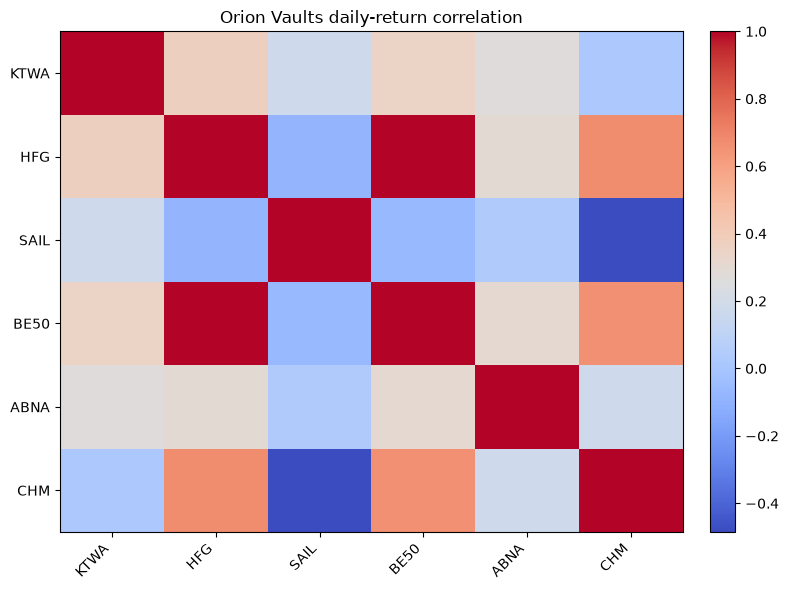

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
vmin = np.nanmin(corr.values)
vmax = np.nanmax(corr.values)
im = ax.imshow(corr.values, vmin=vmin, vmax=vmax, cmap="coolwarm", aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
ax.set_title("Orion Vaults daily-return correlation")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

### Overlay normalized share-price paths

Rebase each series to 1.0 at the first observation so LPs can eyeball relative performance.

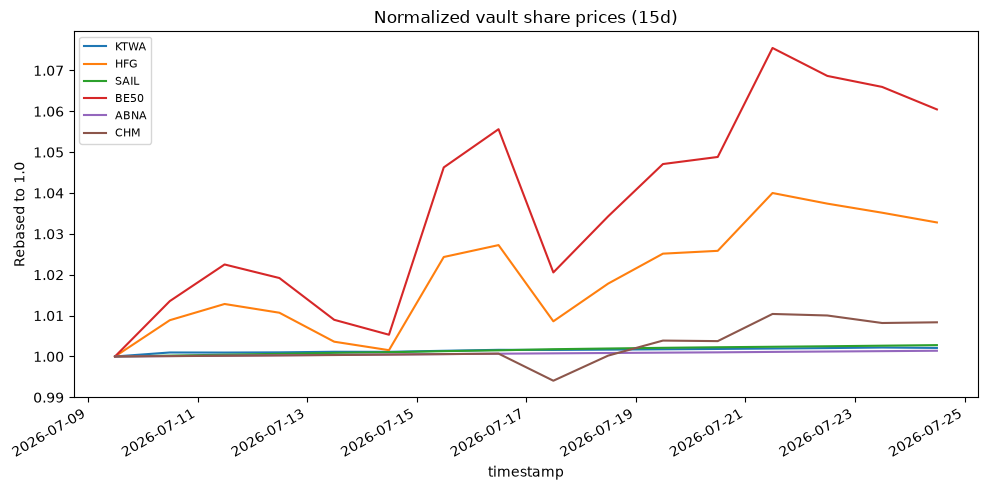

In [25]:
if not prices.empty:
    normalized = prices.divide(prices.dropna(how="all").iloc[0]).dropna(how="all")
    fig, ax = plt.subplots(figsize=(10, 5))
    normalized.plot(ax=ax)
    ax.set_title(f"Normalized vault share prices ({LOOKBACK_DAYS}d)")
    ax.set_ylabel("Rebased to 1.0")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    plt.show()

## 4. Intent vs PIT allocation (expected rebalancing)

For a chosen vault:

- `get_intent()` — strategist **target** weights for the next rebalance (fractions, sum ≈ 1)
- `get_portfolio_pct_tvl()` — **current** book estimated with PIT oracle prices

The gap is the **expected rebalancing**. Pick a vault with a non-empty intent when possible.

In [29]:
focus_vault: OrionTransparentVault | None = None

if active_vaults:
    focus_vault = active_vaults[0]

assert focus_vault is not None

intent = focus_vault.get_intent()
current = focus_vault.get_portfolio_pct_tvl()

# Align on the union of tokens
all_tokens = sorted(set(intent) | set(current), key=lambda a: label_asset(a))
compare = pd.DataFrame(
    {
        "intent": [intent.get(t, 0.0) for t in all_tokens],
        "current": [current.get(t, 0.0) for t in all_tokens],
    },
    index=[label_asset(t) for t in all_tokens],
)
compare["delta"] = compare["intent"] - compare["current"]

compare = compare.map(lambda x: float(f"{x:.4f}"))

compare

,intent,current,delta
DAI-1 yVault,0.0049,0.0049,-0.0000
DAI-2 yVault,0.0004,0.0004,-0.0000
EVK Vault eRLUSD-7,0.0327,0.0327,-0.0000
EVK Vault eUSDe-6,0.0003,0.0003,-0.0000
Savings Dai,0.0883,0.0885,-0.0001
Staked FRAX,0.0335,0.0335,-0.0000
Staked USDe,0.7906,0.7908,-0.0003
Steakhouse ETH,0.0000,0.0000,0.0000
Steakhouse Prime EURCV,0.0493,0.0489,0.0004
USDC,0.0000,0.0000,-0.0000


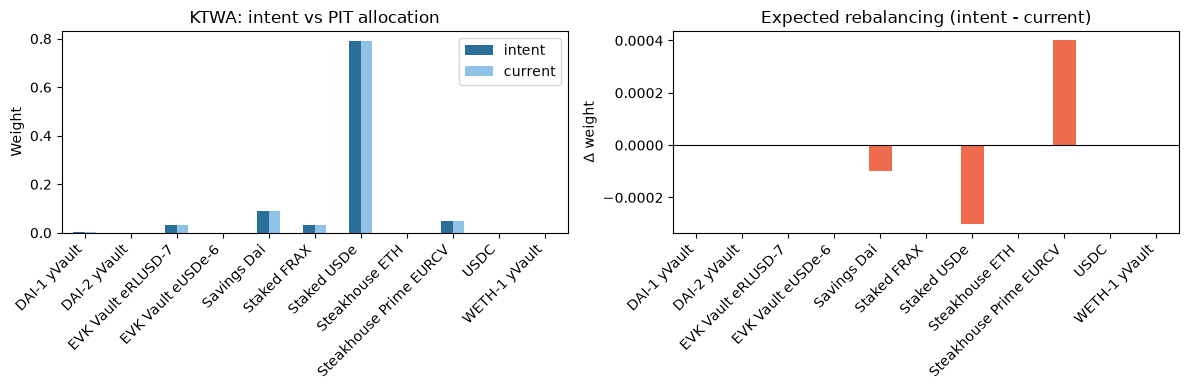

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

compare[["intent", "current"]].plot(
    kind="bar", ax=axes[0], color=["#2a6f97", "#90c2e7"]
)
axes[0].set_title(f"{focus_vault.symbol}: intent vs PIT allocation")
axes[0].set_ylabel("Weight")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(loc="best")
fig.autofmt_xdate(rotation=45, ha='right')

compare["delta"].plot(kind="bar", ax=axes[1], color="#ee6c4d")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Expected rebalancing (intent - current)")
axes[1].set_ylabel("Δ weight")
axes[1].tick_params(axis="x", rotation=45)
fig.autofmt_xdate(rotation=45, ha='right')

fig.tight_layout()
plt.show()

## 5. LP view: performance distribution across vaults

From the share-price panel, compute each vault’s **total return** over the window
(and optionally daily-return volatility). Plot the cross-section so an LP can see
how products on the infrastructure are distributed, not just one vault in isolation.

In [34]:
perf_rows: list[dict] = []
for col in prices.columns:
    s = prices[col].dropna()
    if len(s) < 2:
        continue
    total_return = float(s.iloc[-1] / s.iloc[0] - 1.0)
    vol = float(returns[col].dropna().std()) if col in returns else float("nan")
    perf_rows.append(
        {
            "symbol": col,
            "total_return": total_return,
            "daily_vol": vol,
            "n_obs": len(s),
        }
    )

perf = pd.DataFrame(perf_rows).sort_values("total_return")
perf

,symbol,total_return,daily_vol,n_obs
4,ABNA,0.001400,0.000007,16
0,KTWA,0.002090,0.000251,16
2,SAIL,0.002779,0.000050,16
5,CHM,0.008364,0.003144,16
1,HFG,0.032800,0.009555,16
3,BE50,0.060463,0.016984,16


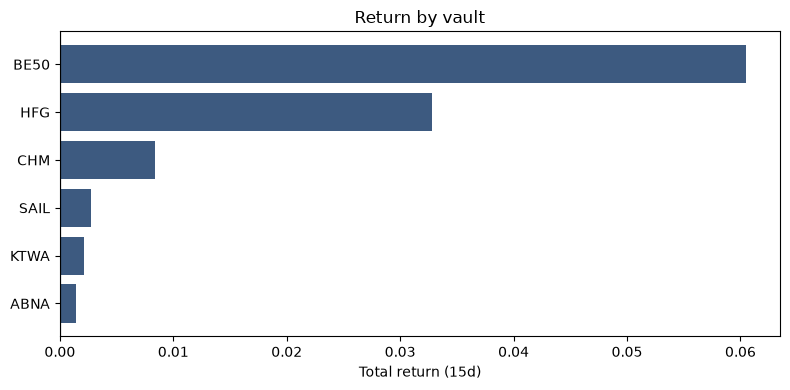

In [36]:
if perf.empty:
    print("Not enough history to plot a return distribution.")
else:
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))

    ax.barh(perf["symbol"], perf["total_return"], color="#3d5a80")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel(f"Total return ({LOOKBACK_DAYS}d)")
    ax.set_title("Return by vault")

    fig.tight_layout()
    plt.show()